In [1]:
import sys
import os

ROOT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.append(ROOT_DIR)
os.chdir(ROOT_DIR)

/home/mei/miniforge3/envs/robodiff/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mei/miniforge3/envs/robodiff/lib/python3.9/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/mei/workspace/diffusion_policy/diffusion_policy/dataset/real_lowdim_dataset.py:274: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize('../config'):
/home/mei/workspace/diffusion_policy/diffusion_policy/dataset/real_lowdim

Acquiring lock on cache.
Loading cached ReplayBuffer from Disk.
Loaded!


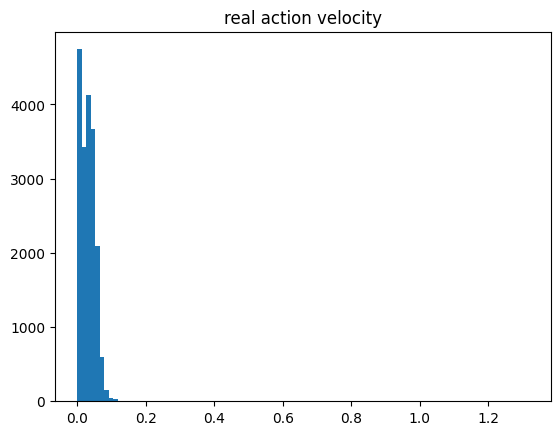

In [2]:
from diffusion_policy.dataset.real_lowdim_dataset import test

test()

In [4]:
# Test DiffusionUnetLowdimPolicy with shape_meta parsing
import torch
import numpy as np
from diffusion_policy.policy.diffusion_unet_lowdim_policy_mei import DiffusionUnetLowdimPolicy
from diffusion_policy.model.diffusion.conditional_unet1d import ConditionalUnet1D
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler

def test_obs_dim_calculation():
    """Test that obs_dim is correctly calculated from shape_meta"""
    print("Testing obs_dim calculation from shape_meta...")
    
    # Test case 1: Simple lowdim observations
    shape_meta_1 = {
        'obs': {
            'robot_eef_pose': {'shape': [3], 'type': 'low_dim'},
            'robot_eef_force': {'shape': [6], 'type': 'low_dim'}
        },
        'action': {'shape': [3]}
    }
    
    # Create minimal UNet model for testing
    model = ConditionalUnet1D(
        input_dim=3,  # action_dim
        local_cond_dim=None,
        global_cond_dim=9,  # obs_dim (3+6)
        diffusion_step_embed_dim=128,
        down_dims=[64, 128],
        kernel_size=3,
        n_groups=8
    )
    
    scheduler = DDPMScheduler(
        num_train_timesteps=100,
        beta_start=0.0001,
        beta_end=0.02,
        beta_schedule="squaredcos_cap_v2",
        clip_sample=True,
        prediction_type="epsilon"
    )
    
    # Create policy
    policy = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta_1,
        model=model,
        noise_scheduler=scheduler,
        horizon=16,
        n_action_steps=8,
        n_obs_steps=2,
        obs_as_global_cond=True,
        pred_action_steps_only=True
    )
    
    expected_obs_dim = 3 + 6  # pose + force
    print(f"Expected obs_dim: {expected_obs_dim}")
    print(f"Calculated obs_dim: {policy.obs_dim}")
    assert policy.obs_dim == expected_obs_dim, f"Expected {expected_obs_dim}, got {policy.obs_dim}"
    print("✓ Test case 1 passed!")
    
    # Test case 2: Mixed observation types (should only count low_dim)
    shape_meta_2 = {
        'obs': {
            'camera': {'shape': [224, 224, 3], 'type': 'rgb'},  # Should be ignored
            'robot_pose': {'shape': [7], 'type': 'low_dim'},
            'gripper_state': {'shape': [1], 'type': 'low_dim'},
            'lidar': {'shape': [100]}  # No type specified, defaults to low_dim
        },
        'action': {'shape': [4]}
    }
    
    model_2 = ConditionalUnet1D(
        input_dim=4,
        global_cond_dim=8,  # 7+1+100
        diffusion_step_embed_dim=128,
        down_dims=[64, 128],
        kernel_size=3,
        n_groups=8
    )
    
    policy_2 = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta_2,
        model=model_2,
        noise_scheduler=scheduler,
        horizon=16,
        n_action_steps=8,
        n_obs_steps=2,
        obs_as_global_cond=True,
        pred_action_steps_only=True
    )
    
    expected_obs_dim_2 = 7 + 1 + 100  # pose + gripper + lidar (camera ignored)
    print(f"\nTest case 2:")
    print(f"Expected obs_dim: {expected_obs_dim_2}")
    print(f"Calculated obs_dim: {policy_2.obs_dim}")
    assert policy_2.obs_dim == expected_obs_dim_2, f"Expected {expected_obs_dim_2}, got {policy_2.obs_dim}"
    print("✓ Test case 2 passed!")
    
    print("\n✅ All obs_dim calculation tests passed!")

def test_policy_forward_pass():
    """Test that policy can do forward passes without errors"""
    print("\nTesting policy forward pass...")
    
    shape_meta = {
        'obs': {
            'robot_eef_pose': {'shape': [3], 'type': 'low_dim'},
            'robot_eef_force': {'shape': [6], 'type': 'low_dim'}
        },
        'action': {'shape': [3]}
    }
    
    obs_dim = 9  # 3 + 6
    action_dim = 3
    horizon = 16
    n_obs_steps = 2
    n_action_steps = 8
    
    model = ConditionalUnet1D(
        input_dim=action_dim,
        global_cond_dim=obs_dim * n_obs_steps,
        diffusion_step_embed_dim=128,
        down_dims=[64, 128],
        kernel_size=3,
        n_groups=8
    )
    
    scheduler = DDPMScheduler(
        num_train_timesteps=100,
        beta_start=0.0001,
        beta_end=0.02,
        beta_schedule="squaredcos_cap_v2",
        clip_sample=True,
        prediction_type="epsilon"
    )
    
    policy = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta,
        model=model,
        noise_scheduler=scheduler,
        horizon=horizon,
        n_action_steps=n_action_steps,
        n_obs_steps=n_obs_steps,
        obs_as_global_cond=True,
        pred_action_steps_only=True,
        num_inference_steps=10  # Fast inference for testing
    )
    
    # Create mock normalizer
    from diffusion_policy.model.common.normalizer import LinearNormalizer
    normalizer = LinearNormalizer()
    
    # Create dummy data for normalizer
    dummy_obs = torch.randn(100, n_obs_steps, obs_dim)
    dummy_action = torch.randn(100, n_action_steps, action_dim)
    
    # normalizer['obs'].fit(dummy_obs)
    # normalizer['action'].fit(dummy_action)
    policy.set_normalizer(normalizer)
    
    # Test predict_action
    batch_size = 2
    obs_dict = {
        'obs': torch.randn(batch_size, n_obs_steps, obs_dim)
    }
    
    print(f"Input obs shape: {obs_dict['obs'].shape}")
    
    with torch.no_grad():
        result = policy.predict_action(obs_dict)
    
    print(f"Output action shape: {result['action'].shape}")
    print(f"Expected action shape: ({batch_size}, {n_action_steps}, {action_dim})")
    
    expected_action_shape = (batch_size, n_action_steps, action_dim)
    assert result['action'].shape == expected_action_shape, f"Expected {expected_action_shape}, got {result['action'].shape}"
    
    print("✓ Forward pass test passed!")
    
    # Test compute_loss
    batch = {
        'obs': torch.randn(batch_size, horizon, obs_dim),
        'action': torch.randn(batch_size, horizon, action_dim)
    }
    
    print(f"\nTesting compute_loss...")
    print(f"Batch obs shape: {batch['obs'].shape}")
    print(f"Batch action shape: {batch['action'].shape}")
    
    loss = policy.compute_loss(batch)
    print(f"Loss: {loss.item():.6f}")
    assert loss.item() >= 0, "Loss should be non-negative"
    assert torch.isfinite(loss), "Loss should be finite"
    
    print("✓ Compute loss test passed!")
    print("\n✅ All policy forward pass tests passed!")

def test_different_conditioning_modes():
    """Test different conditioning modes"""
    print("\nTesting different conditioning modes...")
    
    shape_meta = {
        'obs': {
            'robot_state': {'shape': [8], 'type': 'low_dim'}
        },
        'action': {'shape': [4]}
    }
    
    obs_dim = 8
    action_dim = 4
    horizon = 12
    n_obs_steps = 3
    n_action_steps = 6
    
    scheduler = DDPMScheduler(
        num_train_timesteps=50,
        beta_start=0.0001,
        beta_end=0.02,
        prediction_type="epsilon"
    )
    
    # Test 1: Global conditioning
    model_global = ConditionalUnet1D(
        input_dim=action_dim,
        global_cond_dim=obs_dim * n_obs_steps,
        diffusion_step_embed_dim=64,
        down_dims=[32, 64],
        kernel_size=3,
        n_groups=4
    )
    
    policy_global = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta,
        model=model_global,
        noise_scheduler=scheduler,
        horizon=horizon,
        n_action_steps=n_action_steps,
        n_obs_steps=n_obs_steps,
        obs_as_global_cond=True,
        num_inference_steps=5
    )
    
    print("✓ Global conditioning policy created")
    
    # Test 2: Local conditioning  
    model_local = ConditionalUnet1D(
        input_dim=action_dim,
        local_cond_dim=obs_dim,
        diffusion_step_embed_dim=64,
        down_dims=[32, 64],
        kernel_size=3,
        n_groups=4
    )
    
    policy_local = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta,
        model=model_local,
        noise_scheduler=scheduler,
        horizon=horizon,
        n_action_steps=n_action_steps,
        n_obs_steps=n_obs_steps,
        obs_as_local_cond=True,
        num_inference_steps=5
    )
    
    print("✓ Local conditioning policy created")
    
    # Test 3: Inpainting (no explicit conditioning)
    model_inpaint = ConditionalUnet1D(
        input_dim=action_dim + obs_dim,
        diffusion_step_embed_dim=64,
        down_dims=[32, 64],
        kernel_size=3,
        n_groups=4
    )
    
    policy_inpaint = DiffusionUnetLowdimPolicy(
        shape_meta=shape_meta,
        model=model_inpaint,
        noise_scheduler=scheduler,
        horizon=horizon,
        n_action_steps=n_action_steps,
        n_obs_steps=n_obs_steps,
        num_inference_steps=5
    )
    
    print("✓ Inpainting policy created")
    print("\n✅ All conditioning mode tests passed!")

# Run all tests
if __name__ == "__main__":
    print("🧪 Running DiffusionUnetLowdimPolicy tests...\n")
    
    try:
        test_obs_dim_calculation()
        test_policy_forward_pass() 
        test_different_conditioning_modes()
        
        print("\n🎉 All tests passed successfully!")
        
    except Exception as e:
        print(f"\n❌ Test failed with error: {e}")
        import traceback
        traceback.print_exc()

# Run the tests
test_obs_dim_calculation()
test_policy_forward_pass()
test_different_conditioning_modes()

print("\n🎉 All DiffusionUnetLowdimPolicy tests completed successfully!")

🧪 Running DiffusionUnetLowdimPolicy tests...

Testing obs_dim calculation from shape_meta...
Expected obs_dim: 9
Calculated obs_dim: 9
✓ Test case 1 passed!

Test case 2:
Expected obs_dim: 108
Calculated obs_dim: 108
✓ Test case 2 passed!

✅ All obs_dim calculation tests passed!

Testing policy forward pass...
Input obs shape: torch.Size([2, 2, 9])

❌ Test failed with error: 'ParameterDict' object has no attribute 'obs'
Testing obs_dim calculation from shape_meta...
Expected obs_dim: 9
Calculated obs_dim: 9
✓ Test case 1 passed!

Test case 2:
Expected obs_dim: 108
Calculated obs_dim: 108
✓ Test case 2 passed!

✅ All obs_dim calculation tests passed!

Testing policy forward pass...
Input obs shape: torch.Size([2, 2, 9])


Traceback (most recent call last):
  File "/tmp/ipykernel_163637/3413919370.py", line 294, in <module>
    test_policy_forward_pass()
  File "/tmp/ipykernel_163637/3413919370.py", line 168, in test_policy_forward_pass
    result = policy.predict_action(obs_dict)
  File "/home/mei/workspace/diffusion_policy/diffusion_policy/policy/diffusion_unet_lowdim_policy_mei.py", line 124, in predict_action
    nobs = self.normalizer.normalize(obs_dict)
  File "/home/mei/workspace/diffusion_policy/diffusion_policy/model/common/normalizer.py", line 68, in normalize
    return self._normalize_impl(x, forward=True)
  File "/home/mei/workspace/diffusion_policy/diffusion_policy/model/common/normalizer.py", line 58, in _normalize_impl
    params = self.params_dict[key]
  File "/home/mei/miniforge3/envs/robodiff/lib/python3.9/site-packages/torch/nn/modules/container.py", line 603, in __getitem__
    return getattr(self, attr)
  File "/home/mei/miniforge3/envs/robodiff/lib/python3.9/site-packages/torch/nn/

AttributeError: 'ParameterDict' object has no attribute 'obs'